In [1]:
2*4

8

In [2]:
import os
import tensorflow as tf
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import keras

from tensorflow.keras import layers, models


In [3]:
from DG.OptimizedDataGenerator_v2 import OptimizedDataGenerator
from losses.loss import custom_loss
from models.SoftQuantizeLayer import SoftQuantizeLayer
from models.models import CreateModel # Conv2D model

pi = 3.14159265359

maxval=1e9
minval=1e-9

In [4]:
base = "/work/projects/SmartPixML/dataset_3s_10ps_50x12P5/trained_models/model-c2b6dd60-checkpoints/checkpoints"
os.listdir(base)

['weights.749-t-17663.25-v-16545.28.hdf5',
 'weights.908-t-18638.51-v-13846.00.hdf5',
 'weights.38-t-10122.00-v-10464.89.hdf5',
 'weights.884-t-17962.43-v-17755.43.hdf5',
 'weights.667-t-18045.30-v-15036.26.hdf5',
 'weights.574-t-18419.11-v-19139.86.hdf5',
 'weights.996-t-17944.17-v-18359.90.hdf5',
 'weights.107-t-11189.12-v-11659.65.hdf5',
 'weights.640-t-18196.28-v-17700.64.hdf5',
 'weights.489-t-17437.89-v-14247.34.hdf5',
 'weights.559-t-18406.74-v-18287.36.hdf5',
 'weights.793-t-18096.62-v-17969.70.hdf5',
 'weights.831-t-18329.49-v-18777.83.hdf5',
 'weights.821-t-18318.24-v-18613.85.hdf5',
 'weights.800-t-18074.54-v-19180.82.hdf5',
 'weights.775-t-18264.20-v-18193.76.hdf5',
 'weights.295-t-16560.92-v-16739.86.hdf5',
 'weights.498-t-17621.99-v-17377.33.hdf5',
 'weights.75-t-10308.80-v-10733.27.hdf5',
 'weights.692-t-18133.51-v-17081.44.hdf5',
 'weights.673-t-18281.94-v-19121.88.hdf5',
 'weights.682-t-18319.96-v-18170.51.hdf5',
 'weights.287-t-16174.53-v-16641.56.hdf5',
 'weights.94-

In [5]:
# base_dir = f'/home/das214/work/users/das214/SmartPixels/SoftQuantize/trained_models/Transformer_model-{fingerprint}-checkpoints'
base_dir = "/work/projects/SmartPixML/dataset_3s_10ps_50x12P5/trained_models/model-c2b6dd60-checkpoints/"

plot_dir = os.path.join(base_dir, 'plots')
checkpoints_dir = os.path.join(base_dir, 'checkpoints')
training_cp_path = os.path.join(base_dir, 'training_log.csv')
training_history = pd.read_csv(training_cp_path)

os.makedirs(plot_dir, exist_ok=True)

checkpoint_files = sorted([os.path.join(checkpoints_dir, f) for f in os.listdir(checkpoints_dir) if f.endswith('.hdf5')])
checkpoint_files

['/work/projects/SmartPixML/dataset_3s_10ps_50x12P5/trained_models/model-c2b6dd60-checkpoints/checkpoints/weights.01-t81876.30-v23412.83.hdf5',
 '/work/projects/SmartPixML/dataset_3s_10ps_50x12P5/trained_models/model-c2b6dd60-checkpoints/checkpoints/weights.02-t16039.08-v11164.73.hdf5',
 '/work/projects/SmartPixML/dataset_3s_10ps_50x12P5/trained_models/model-c2b6dd60-checkpoints/checkpoints/weights.03-t7779.89-v5552.85.hdf5',
 '/work/projects/SmartPixML/dataset_3s_10ps_50x12P5/trained_models/model-c2b6dd60-checkpoints/checkpoints/weights.04-t3917.50-v3613.32.hdf5',
 '/work/projects/SmartPixML/dataset_3s_10ps_50x12P5/trained_models/model-c2b6dd60-checkpoints/checkpoints/weights.05-t1753.26-v382.30.hdf5',
 '/work/projects/SmartPixML/dataset_3s_10ps_50x12P5/trained_models/model-c2b6dd60-checkpoints/checkpoints/weights.06-t-409.14-v-1120.62.hdf5',
 '/work/projects/SmartPixML/dataset_3s_10ps_50x12P5/trained_models/model-c2b6dd60-checkpoints/checkpoints/weights.07-t-1890.95-v-2463.93.hdf5',


In [6]:
model=CreateModel(shape = (13,21,2), output = 14, n_filters=5,pool_size=3)
model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3, clipnorm=1.0),
    loss=custom_loss,
)

model.summary()

2025-12-03 06:37:12.013052: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1163 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB MIG 1g.5gb, pci bus id: 0000:81:00.0, compute capability: 8.0
2025-12-03 06:37:12.164806: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 13, 21, 2)]       0         
                                                                 
 q_separable_conv2d (QSepar  (None, 11, 19, 5)         33        
 ableConv2D)                                                     
                                                                 
 q_activation (QActivation)  (None, 11, 19, 5)         0         
                                                                 
 q_conv2d (QConv2D)          (None, 11, 19, 5)         30        
                                                                 
 q_activation_1 (QActivatio  (None, 11, 19, 5)         0         
 n)                                                              
                                                                 
 average_pooling2d (Average  (None, 3, 6, 5)           0     

In [7]:
def extract_val_metric(fname):
    try:
        val_str = fname.split("-v-")[-1].replace(".hdf5", "")
        return float(val_str)
    except Exception:
        return float("-inf")

best_ckpt = None
best_val = float("-inf")

for f in checkpoint_files:
    val = extract_val_metric(os.path.basename(f))
    if val > best_val:
        best_val = val
        best_ckpt = f

print(f"Loading model from {best_ckpt}")
model.load_weights(best_ckpt)

Loading model from /work/projects/SmartPixML/dataset_3s_10ps_50x12P5/trained_models/model-c2b6dd60-checkpoints/checkpoints/weights.953-t-19271.26-v-20620.14.hdf5


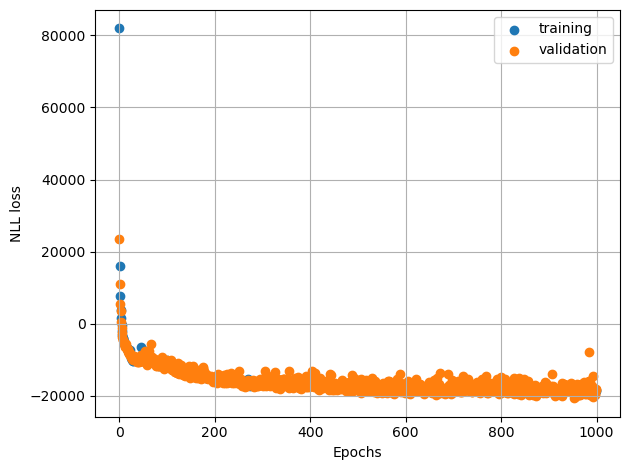

In [8]:
plt.scatter(training_history['epoch'], training_history['loss'])
plt.scatter(training_history['epoch'], training_history['val_loss'])
plt.legend(['training', 'validation'])
plt.grid(True)
plt.xlabel('Epochs')
plt.ylabel('NLL loss')
plt.tight_layout() 

plt.savefig(os.path.join(base_dir,'training_hist.png'))
plt.show()

In [13]:
# dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/"

# NOISE_MU = 0.0
# NOISE_SIGMA = 400.0 # e-

# tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", f"2t_N_{NOISE_MU}mu_{NOISE_SIGMA}sig")
# tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
# tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")


In [9]:
# dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_3sr/dataset_3sr_16x16_50x12P5_parquets/contained"
#dataset_base_dir = '/depot/cms/users/das214/datasets/temporary/preamp_response/'
#tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", "2t")
#dataset_train_dir = os.path.join(dataset_base_dir, "train")
#dataset_test_dir = os.path.join(dataset_base_dir, "test")
#tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
#tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")

#batch_size = 5000
#val_batch_size = 5000
#train_file_size = len(os.listdir(dataset_train_dir))
#val_file_size = len(os.listdir(dataset_test_dir))




dataset_base_dir = '/work/projects/SmartPixML/dataset_3s_10ps_50x12P5/'
tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", "2t")

dataset_train_dir = os.path.join(dataset_base_dir, "train")
dataset_test_dir = os.path.join(dataset_base_dir, "test")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")

batch_size = 5000
val_batch_size = 5000
train_file_size = len(os.listdir(dataset_train_dir))
val_file_size = len(os.listdir(dataset_test_dir))

In [10]:
test_generator = OptimizedDataGenerator(
    load_from_tfrecords_dir= tfrecords_dir_val,
    shuffle=True,
    seed=42,
    quantize=True,
)
labels_scale = test_generator.labels_scale
print(labels_scale)

Loading metadata from /work/projects/SmartPixML/dataset_3s_10ps_50x12P5/TFR_files/2t/TFR_val/metadata.json
[74.35833351 18.61257416  8.58538849  0.35536798]


In [11]:
# predicts test data
p_test = model.predict(test_generator)

 3/16 [====>.........................] - ETA: 0s

2025-12-03 06:37:41.049965: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907


16/16 [==============================] - 2s 101ms/step


In [12]:
complete_truth = None
for _, y in tqdm(test_generator):
        if complete_truth is None:
            complete_truth = y
        else:
            complete_truth = np.concatenate((complete_truth, y), axis=0)

100%|██████████| 16/16 [00:01<00:00, 14.80it/s]


In [13]:
def softplus(x):
    x = np.asarray(x)
    return np.maximum(x, 0) + np.log1p(np.exp(-np.abs(x)))

In [16]:
# creates df with all predicted values and matrix elements - 4 predictions, all 10 unique matrix elements
df = pd.DataFrame(p_test,columns=['x','M11','y','M22','cotA','M33','cotB','M44','M21','M31','M32','M41','M42','M43'])

# stores all true values in same matrix as xtrue, ytrue, etc.
df['xtrue'] = complete_truth[:,0]
df['ytrue'] = complete_truth[:,1]
df['cotAtrue'] = complete_truth[:,2]
df['cotBtrue'] = complete_truth[:,3]
df['M11'] = minval+tf.math.maximum(df['M11'], 0)
df['M22'] = minval+tf.math.maximum(df['M22'], 0)
df['M33'] = minval+tf.math.maximum(df['M33'], 0)
df['M44'] = minval+tf.math.maximum(df['M44'], 0)

df['sigmax'] = abs(df['M11'])
df['sigmay'] = np.sqrt(df['M21']**2 + df['M22']**2)
df['sigmacotA'] = np.sqrt(df['M31']**2+df['M32']**2+df['M33']**2)
df['sigmacotB'] = np.sqrt(df['M41']**2+df['M42']**2+df['M43']**2+df['M44']**2)

# calculates residuals for x, y, cotA, cotB
residuals = df['xtrue'] - df['x']
residualsy = df['ytrue'] - df['y']
residualsA = df['cotAtrue'] - df['cotA']
residualsB = df['cotBtrue'] - df['cotB']

# stores results as csv
df.to_csv(os.path.join(base_dir, "test_4x4.csv"),header=True,index=False)
df.to_parquet(os.path.join(base_dir, "2t_Conv2D_10ps_Charge.parquet"))



In [17]:
df7= pd.read_parquet(os.path.join(base_dir, "2t_Conv2D_10ps_Charge.parquet"))
df7.head()

,x,M11,y,M22,cotA,M33,cotB,M44,M21,M31,...,M42,M43,xtrue,ytrue,cotAtrue,cotBtrue,sigmax,sigmay,sigmacotA,sigmacotB
0,-0.468384,0.119690,0.851074,0.108215,-0.311218,0.050049,-0.083435,0.176270,-0.022705,-0.010864,...,-0.003723,-0.039734,-0.129811,0.865489,-0.313227,-0.462210,0.119690,0.110572,0.051249,0.181939
1,-0.788147,0.089844,-0.631042,0.049316,0.455322,0.019043,0.627625,0.110535,0.060425,-0.008850,...,-0.018127,0.054626,-0.863278,-0.522394,0.468347,0.600080,0.089844,0.077995,0.022321,0.125149
2,-0.323547,0.121033,-0.415222,0.109070,-0.075989,0.050110,-0.229919,0.208130,-0.019043,-0.006897,...,0.023193,-0.029907,-0.291459,-0.450217,-0.106681,-0.201220,0.121033,0.110720,0.051340,0.212050
3,0.185913,0.184143,-0.923035,0.036621,-0.956238,0.043396,0.398560,0.093140,-0.041992,-0.004395,...,0.023193,-0.068787,0.181220,-0.876231,-0.909648,0.435377,0.184143,0.055718,0.043742,0.119854
4,-0.629456,0.117615,-0.260071,0.044373,-0.572144,0.033813,0.348450,0.075562,-0.042969,-0.003174,...,0.015015,-0.059265,-0.775406,-0.255981,-0.576360,0.240100,0.117615,0.061768,0.034008,0.097946


In [47]:
os.path.join(base_dir, "2t_Conv2D_10ps_Charge.parquet")

'/work/projects/SmartPixML/dataset_3s_10ps_50x12P5/trained_models/model-c2b6dd60-checkpoints/2t_Conv2D_10ps_Charge.parquet'

In [48]:
df.head()

,x,M11,y,M22,cotA,M33,cotB,M44,M21,M31,...,pully,pullcotA,pullcotB,residualx,residualy,angle,angleup,angledown,angletrue,residualangle
0,-0.468384,0.119690,0.851074,0.108215,-0.311218,0.050049,-0.083435,0.176270,-0.022705,-0.010864,...,0.130363,-0.039186,-2.081878,25.175684,0.268291,91.698334,3.703171,3.689049,99.327820,7.629486
1,-0.788147,0.089844,-0.631042,0.049316,0.455322,0.019043,0.627625,0.110535,0.060425,-0.008850,...,1.393018,0.583517,-0.220097,-5.586609,2.022235,77.426674,2.403275,2.449081,77.962036,0.535362
2,-0.323547,0.121033,-0.415222,0.109070,-0.075989,0.050110,-0.229919,0.208130,-0.019043,-0.006897,...,-0.316062,-0.597827,0.135343,2.386026,-0.651335,94.671036,4.307190,4.255020,94.090103,-0.580933
3,0.185913,0.184143,-0.923035,0.036621,-0.956238,0.043396,0.398560,0.093140,-0.041992,-0.004395,...,0.840020,1.065102,0.307185,-0.348944,0.871140,81.938515,2.376945,2.405190,81.204987,-0.733528
4,-0.629456,0.117615,-0.260071,0.044373,-0.572144,0.033813,0.348450,0.075562,-0.042969,-0.003174,...,0.066213,-0.123971,-1.106218,-10.852627,0.076122,82.941116,1.955109,1.971756,85.123108,2.181992


# residuals (mean, stdv)

In [49]:
# x
(np.mean(residuals)*labels_scale[0],np.std(residuals)*labels_scale[0])

(0.1497109365371297, 11.592242702318119)

In [50]:
# y
(np.mean(residualsy)*labels_scale[1],np.std(residualsy)*labels_scale[1])

(0.004821930110170499, 1.8864448906978981)

In [51]:
# cotA
(np.mean(residualsA)*labels_scale[2],np.std(residualsA)*labels_scale[2])

(0.03138268836318851, 0.3724814530966373)

In [52]:
# cotB
(np.mean(residualsB)*labels_scale[3],np.std(residualsB)*labels_scale[3])

(-0.00022812872351418538, 0.06759384466647692)

# x residuals

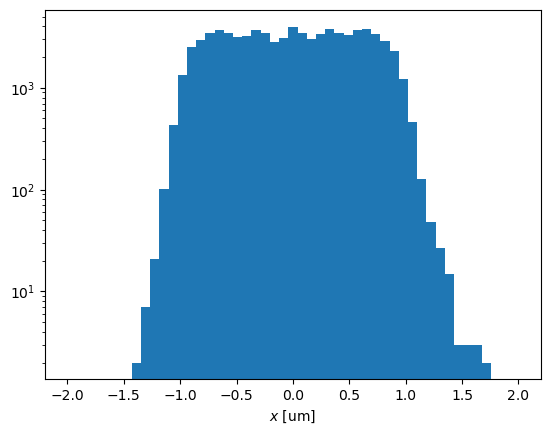

In [53]:
plt.hist(p_test[:,0],bins=np.linspace(-2,2,50))
plt.yscale('log')
plt.xlabel(r'$x$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_dist.png')
plt.savefig(save_fig_path)

plt.show()

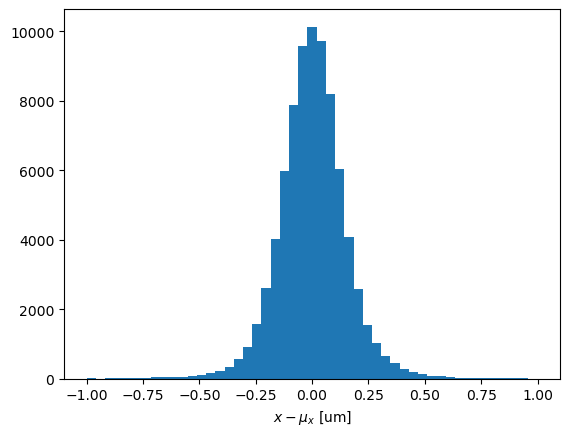

In [54]:
plt.hist(residuals,bins=np.linspace(-1,1,50))
#plt.yscale('Log')
plt.xlabel(r'$x-\mu_x$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

In [55]:
2/50

0.04

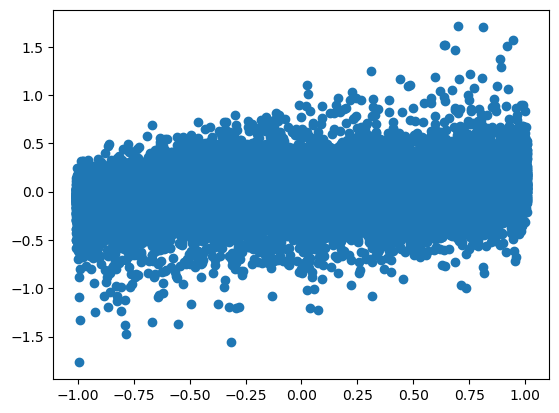

In [56]:
plt.scatter(df['xtrue'], (df['xtrue']-df['x']))
plt.show()

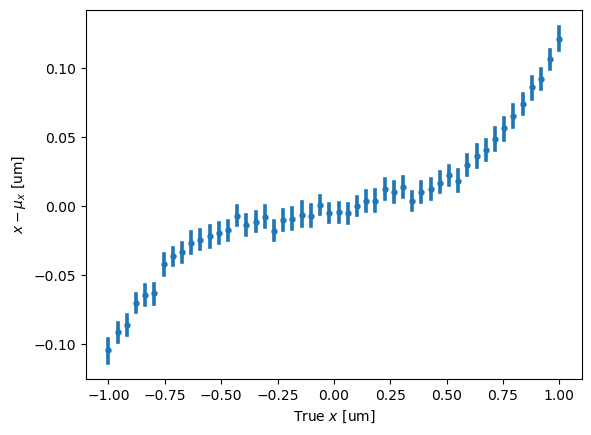

In [57]:
x = sns.regplot(x=df['xtrue'], y=(df['xtrue']-df['x']), x_bins=np.linspace(-1,1,50), fit_reg=None, marker='.')
plt.xlabel(r'True $x$ [um]')
plt.ylabel(r'$x-\mu_x$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# y residuals

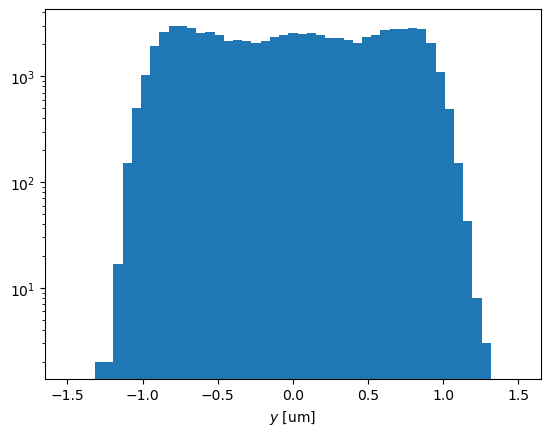

In [58]:
plt.hist(p_test[:,2],bins=np.linspace(-1.5,1.5,50))
plt.yscale('log')
plt.xlabel(r'$y$ [um]')

save_fig_path = os.path.join(plot_dir, 'y_dist.png')
plt.savefig(save_fig_path)

plt.show()

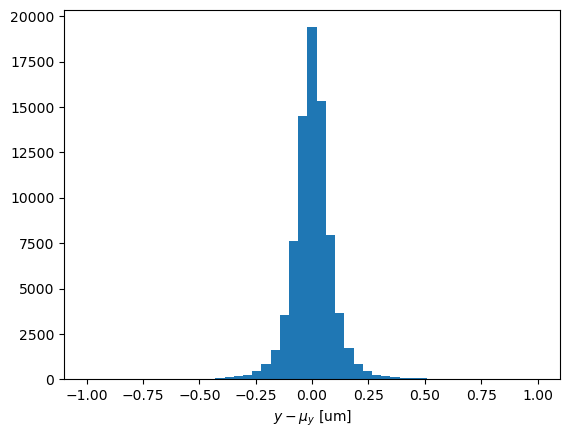

In [59]:
plt.hist(residualsy,bins=np.linspace(-1,1,50))
#plt.yscale('Log')
plt.xlabel(r'$y-\mu_y$ [um]')

save_fig_path = os.path.join(plot_dir, 'y_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

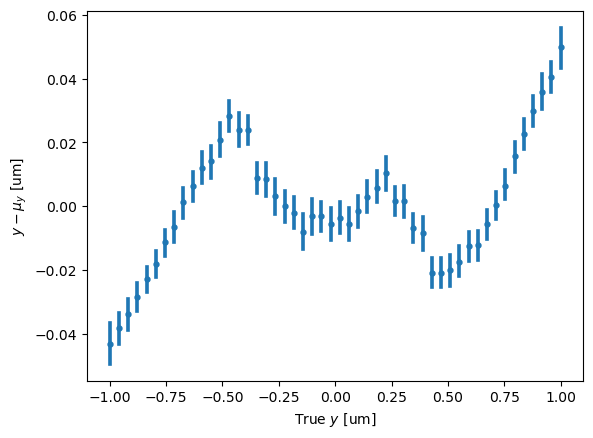

In [60]:
x = sns.regplot(x=df['ytrue'], y=(df['ytrue']-df['y']), x_bins=np.linspace(-1,1,50), fit_reg=None, marker='.')
plt.xlabel(r'True $y$ [um]')
plt.ylabel(r'$y-\mu_y$ [um]')

save_fig_path = os.path.join(plot_dir, 'x_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# cotA residuals

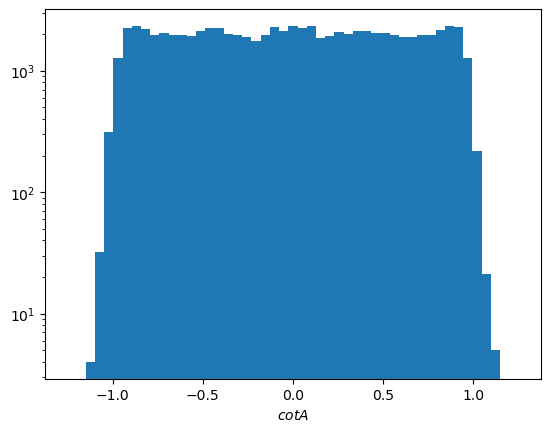

In [61]:
plt.hist(df["cotA"],bins=np.linspace(-1.25,1.25,50))
plt.yscale('log')
plt.xlabel(r'$cotA$')

save_fig_path = os.path.join(plot_dir, 'cotA_dist.png')
plt.savefig(save_fig_path)

plt.show()

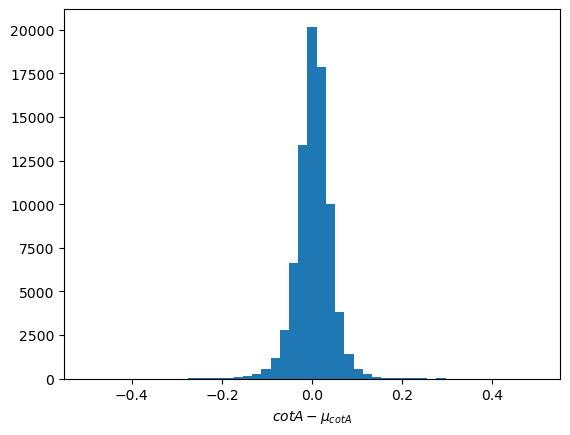

In [62]:
plt.hist(residualsA,bins=np.linspace(-0.5,0.5,50))
#plt.yscale('Log')
plt.xlabel(r'$cotA-\mu_{cotA}$')

save_fig_path = os.path.join(plot_dir, 'cotA_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

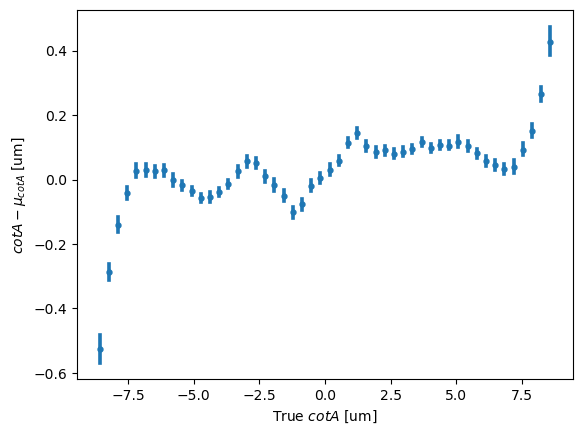

In [63]:
x = sns.regplot(x=df['cotAtrue']*labels_scale[2], y=(df['cotAtrue']-df['cotA'])*labels_scale[2], x_bins=np.linspace(-labels_scale[2],labels_scale[2],50), fit_reg=None, marker='.')
plt.xlabel(r'True $cotA$ [um]')
plt.ylabel(r'$cotA-\mu_{cotA}$ [um]')

save_fig_path = os.path.join(plot_dir, 'cotA_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# cotB residuals

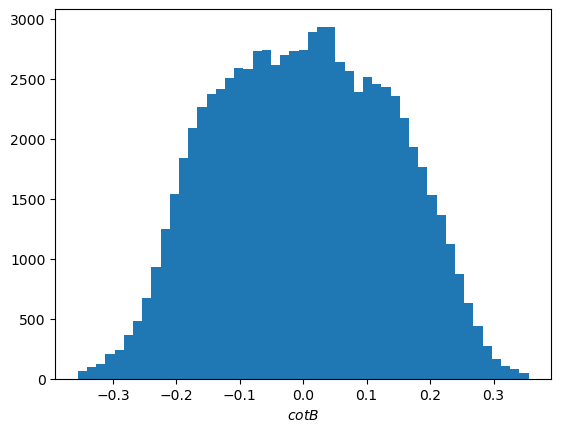

In [64]:
plt.hist(df["cotB"]*labels_scale[3],bins=np.linspace(-labels_scale[3],labels_scale[3],50))
#plt.yscale('Log')
plt.xlabel(r'$cotB$')

save_fig_path = os.path.join(plot_dir, 'cotB_dist.png')
plt.savefig(save_fig_path)

plt.show()

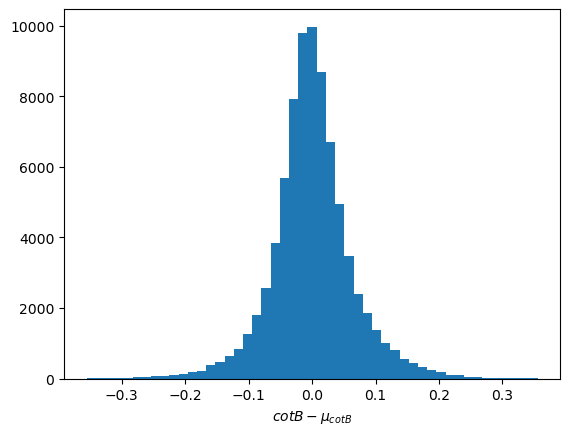

In [65]:
plt.hist(residualsB*labels_scale[3],bins=np.linspace(-labels_scale[3],labels_scale[3],50))
#plt.yscale('Log')
plt.xlabel(r'$cotB-\mu_{cotB}$')

save_fig_path = os.path.join(plot_dir, 'cotB_res_dist.png')
plt.savefig(save_fig_path)

plt.show()

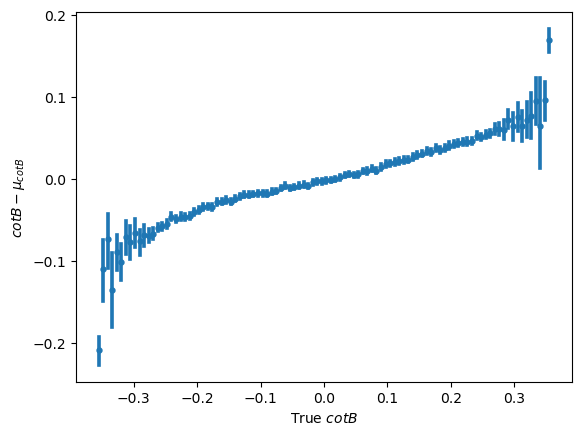

In [66]:
x = sns.regplot(x=df['cotBtrue']*labels_scale[3], y=(df['cotBtrue']-df['cotB'])*labels_scale[3], x_bins=np.linspace(-labels_scale[3],labels_scale[3],100), fit_reg=None, marker='.')
plt.xlabel(r'True $cotB$')
plt.ylabel(r'$cotB-\mu_{cotB} $')

save_fig_path = os.path.join(plot_dir, 'cotB_vs_res.png')
plt.savefig(save_fig_path)

plt.show()

# pull

In [67]:
df['pullx'] = (df['xtrue']-df['x'])/df['sigmax']
df['pully'] = (df['ytrue']-df['y'])/df['sigmay']
df['pullcotA'] = (df['cotAtrue']-df['cotA'])/df['sigmacotA']
df['pullcotB'] = (df['cotBtrue']-df['cotB'])/df['sigmacotB']

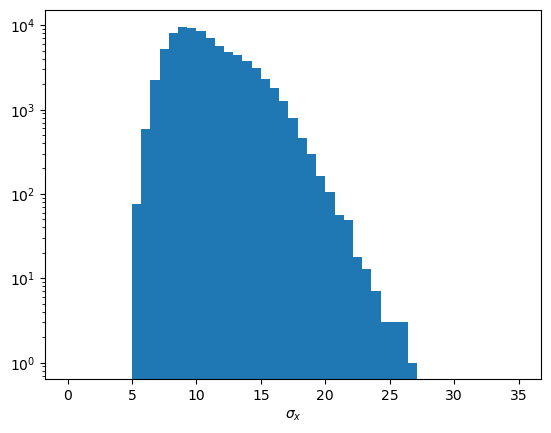

In [68]:
plt.hist(df['sigmax'] *labels_scale[0],bins=np.linspace(0,35,50))
plt.xlabel('$\sigma_{x}$')
plt.yscale('log')

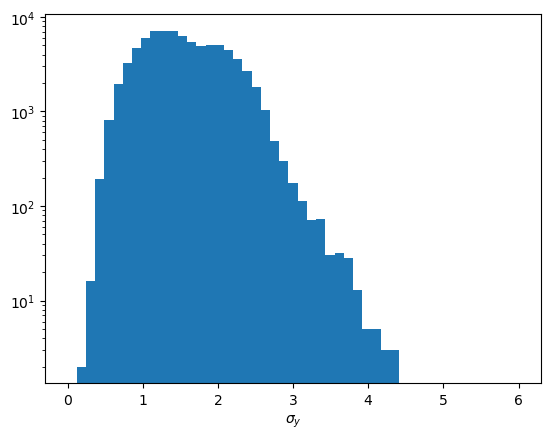

In [69]:
plt.hist(df['sigmay']*labels_scale[1],bins=np.linspace(0,6,50))
plt.xlabel('$\sigma_{y}$')
plt.yscale('log')

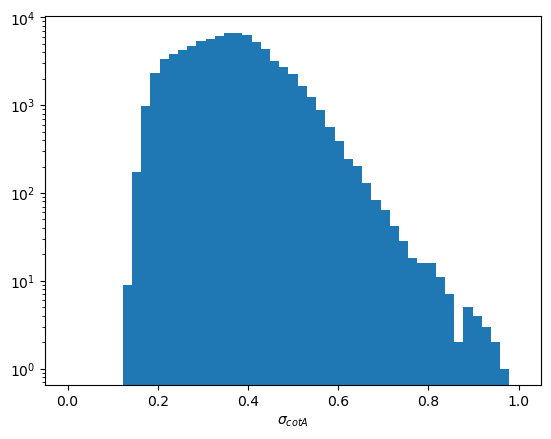

In [70]:
plt.hist(df['sigmacotA'] *labels_scale[2],bins=np.linspace(0,1.0,50))
plt.xlabel('$\sigma_{cotA}$')
plt.yscale('log')

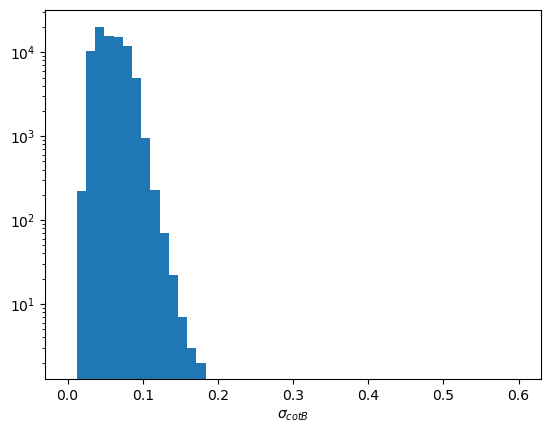

In [71]:
plt.hist(df['sigmacotB'] *labels_scale[3] ,bins=np.linspace(0,0.6,50))
plt.xlabel('$\sigma_{cotB}$')
plt.yscale('log')

In [72]:
from scipy.optimize import curve_fit

def gauss(x, A, mu, sigma):
    return A * np.exp(-(x - mu) ** 2 / (2 * sigma ** 2))

def pull_plot(ax, var, name):
    
    h = ax.hist(df[var],bins=np.linspace(-5,5,50),histtype='step')
    ax.set_xlabel(name)
    ax.set_yscale('log')

    ydata = h[0]
    xdata = h[1][:-1]+3/50.

    pars, cov = curve_fit(gauss,xdata,ydata)

    xbins = np.linspace(-5,5,100)
    ax.plot(xbins,gauss(xbins,pars[0],pars[1],pars[2]),color='black')
    ax.set_ylim(0.5,100000)

    print('Mean',pars[1])
    print('Sigma',pars[2])
    
    ax.text(-5,2000,"$\mu$="+str(round(pars[1],2)))
    ax.text(-5,1000,"$\sigma$="+str(round(abs(pars[2]),2)))

# Pull Plot

Mean -0.029766023583721924
Sigma -0.9044970804490843
Mean -0.021364520155615904
Sigma -0.865462424810178
Mean 0.08171949789308425
Sigma 0.7866541035629647
Mean -0.0828130525120729
Sigma -0.9168387574071099


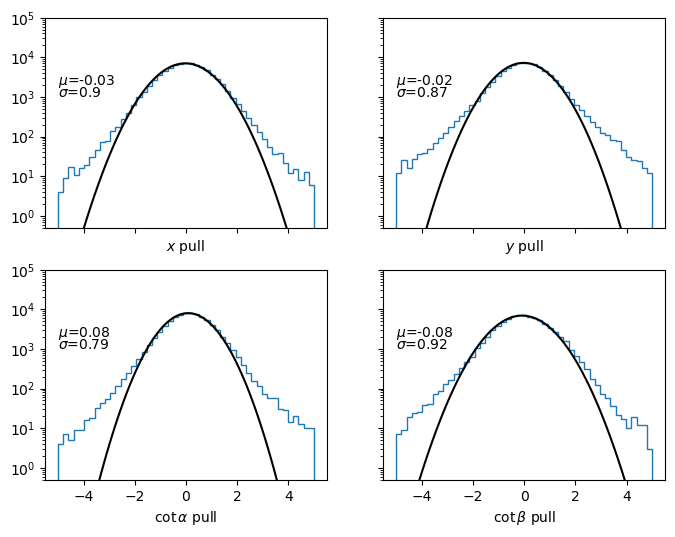

In [73]:
fig, axes = plt.subplots(2,2,sharex=True,sharey=True,figsize=(8,6))
pull_plot(axes[0][0],'pullx',r'$x$ pull')
pull_plot(axes[0][1],'pully',r'$y$ pull')
pull_plot(axes[1][0],'pullcotA',r'$\cot\alpha$ pull')
pull_plot(axes[1][1],'pullcotB',r'$\cot\beta$ pull')

save_fig_path = os.path.join(plot_dir, 'Pull.png')
plt.savefig(save_fig_path)

plt.show()

# Summary

In [74]:
def residual_plot(ax, thisdf, var1, var2, name, scaling=1.0):
    
    nbins = 15
    
    var1_scaled = thisdf[var1] * scaling
    var2_scaled = thisdf[var2] * scaling
    residual_scaled = var1_scaled - var2_scaled
    
    xmin = np.min(var1_scaled)
    xmax = np.max(var1_scaled)
    
    step = 1.0*(xmax-xmin)/nbins
    
    x = sns.regplot(x=var1_scaled, y=residual_scaled, x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax)
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    
    thisdf['residual'+var2] = residual_scaled
    print(var1)
    
    means = []
    upbar = []
    downbar = []
    for i in range(0,nbins):
        means += [np.mean(thisdf['residual'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)])]
        upbar += [means[i] + np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
        downbar += [means[i] - np.mean(thisdf['sigma'+var2][(var1_scaled>xmin + i*step) & (var1_scaled<xmin + (i+1)*step)] * scaling)]
    ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)

def inverse_cot(cota):
    a = np.arctan(1.0/cota)
    a[np.where(a<0)] = a[np.where(a<0)] + pi
    return a    

def residual_plot_deg(ax, thisdf, var1, var2, name, scaling=1.0):
    # positions
    if 'cot' not in var1:
        residual_plot(ax, thisdf, var1, var2, name, scaling=scaling)
        return

    thisdf['angle'] = inverse_cot(thisdf[var2].values * scaling)*180/pi
    
    thisdf['angleup'] = abs(inverse_cot((thisdf[var2].values + thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
    thisdf['angledown'] = abs(inverse_cot((thisdf[var2].values - thisdf['sigma'+var2].values) * scaling)*180/pi - thisdf['angle'])
    thisdf['angletrue'] = inverse_cot(thisdf[var1].values * scaling)*180/pi
        
    var1 = 'angletrue'
    var2 = 'angle'
    
    nbins = 15
    xmin = np.min(thisdf[var1])
    xmax = np.max(thisdf[var1])
    
    step = 1.0*(xmax-xmin)/nbins
        
    x = sns.regplot(x=thisdf[var1], y=(thisdf[var1]-thisdf[var2]), x_bins=np.linspace(xmin,xmax,nbins), fit_reg=None, marker='.', ax=ax)
    ax.set_xlabel('True ' + name)
    ax.set_ylabel('True - predicted ' + name)
    
    thisdf['residual'+var2] = (thisdf[var1]-thisdf[var2])
    print(var1)
    
    means = []    
    upbar = []
    downbar = []
    for i in range(0,nbins):
        means += [np.mean(thisdf['residual'+var2][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        upbar += [means[i] + np.mean(thisdf['angleup'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
        downbar += [means[i] - np.mean(thisdf['angledown'][(thisdf[var1]>xmin + i*step) & (thisdf[var1]<xmin + (i+1)*step)])]
    #ax.scatter(x=np.linspace(xmin,xmax,nbins),y=means)
    ax.fill_between(x=np.linspace(xmin,xmax,nbins),y1=upbar,y2=downbar, alpha=0.2)

# Summary Plot

xtrue
ytrue


/tmp/ipykernel_1265/2844183014.py:31: RuntimeWarning: divide by zero encountered in divide
  a = np.arctan(1.0/cota)


angletrue
angletrue


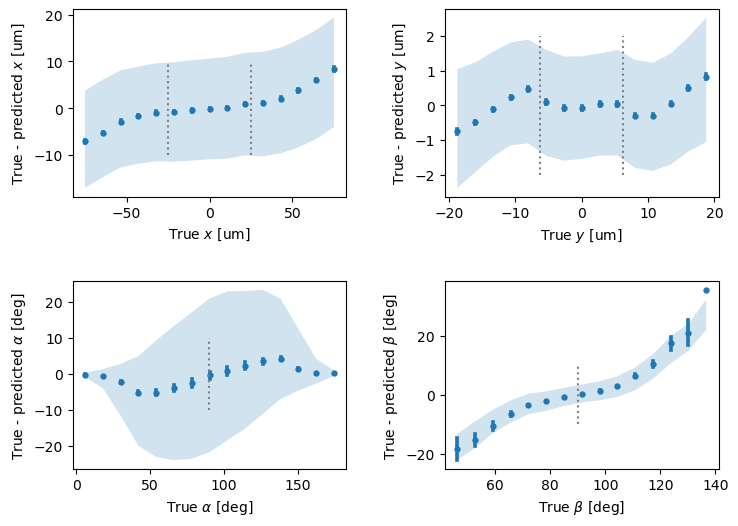

In [75]:
fig, axes = plt.subplots(2,2,figsize=(8,6))
fig.tight_layout(pad=4.0)
residual_plot(axes[0][0],df,'xtrue','x',r'$x$ [um]', scaling=labels_scale[0])
axes[0][0].plot([-25,-25],[-10,10],color='gray',linestyle=':')
axes[0][0].plot([25,25],[-10,10],color='gray',linestyle=':')
residual_plot(axes[0][1],df,'ytrue','y',r'$y$ [um]', scaling=labels_scale[1])
axes[0][1].plot([-6.25,-6.25],[-2,2],color='gray',linestyle=':')
axes[0][1].plot([6.25,6.25],[-2,2],color='gray',linestyle=':')
residual_plot_deg(axes[1][0],df,'cotAtrue','cotA',r'$\alpha$ [deg]', scaling=labels_scale[2])
axes[1][0].plot([90,90],[-10,10],color='gray',linestyle=':')
residual_plot_deg(axes[1][1],df,'cotBtrue','cotB',r'$\beta$ [deg]', scaling=labels_scale[3])
axes[1][1].plot([90,90],[-10,10],color='gray',linestyle=':')

save_fig_path = os.path.join(plot_dir, 'summary.png')
plt.savefig(save_fig_path)